# FIT1043 Introdcution to Data Science
## Assignement 1

Quah Xuanyu \
35624914

This assignment will test my ability to: 
* Read and describe the data using basic statistics, 
* Split the dataset into training and testing, 
* Conduct multi-class classification using Support Vector Machine (SVM)**, 
* Evaluate and compare predictive models, 
* Explore different datasets and select a particular dataset that meets certain criteria 
* Conduct clustering using k-means

---
# Part A1: Data Wrangling (5 Marks)

## Step 1 : Import CSV

In [ ]:
# 1. Read the ‘Student_List_A2.csv’ file and list the column names. 
# Import libraries and read the csv

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline 
df = pd.read_csv('Student_List_A2.csv')

In [ ]:
df.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,1
1,1003,15,4.210570,26,2,0.112602,4
2,1004,17,10.028829,14,3,2.054218,3
3,1005,17,4.672495,17,3,1.288061,4
4,1006,18,8.191219,0,1,3.084184,1


## Step 2 : Replace numerical grade with letter grades

In [ ]:
# 2. Replace missing values
# Create dictionary for the grade
grade_mapping = {
    0: 'A',
    1: 'B',
    2: 'C',
    3: 'D',
    4: 'F'
}

df['GradeClass'] = df['GradeClass'].replace(grade_mapping)

In [ ]:
df.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B


## Step 3: Replace missing values

In [ ]:
# Check which columns has missing values
print(df.isnull().sum())

StudentID           0
Age                 0
StudyTimeWeekly    21
Absences            0
ParentalSupport     0
GPA                 0
GradeClass          0
dtype: int64


From the output above, we can see that StudyTimeWeekly has 21 null (empty) cells

In [ ]:
# Fill the empty cells with the median
df = df.fillna(df.median(numeric_only=True))

In [ ]:
# Check which columns has missing values
print(df.isnull().sum())

StudentID          0
Age                0
StudyTimeWeekly    0
Absences           0
ParentalSupport    0
GPA                0
GradeClass         0
dtype: int64


## Step 4: Identify problems with 'Absences' column

### Steps used:
1. Using describe(), I managed to see that the min and max values are extremly high
2. Then created a new data frame get the rows that are negative and too large
3. Lastly, to confirm my suspicion, I used a box plot to see the outliers

In [ ]:
# Describe the abcenses to check for any errounous values
df["Absences"].describe()

count    2100.000000
mean       14.709048
std        11.153253
min      -122.000000
25%         7.000000
50%        15.000000
75%        22.000000
max       320.000000
Name: Absences, dtype: float64

In [ ]:
problem_rows = df[(df['Absences'] < 0) | (df['Absences'] > 100) ]
problem_rows

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
112,1114,16,16.849282,320,1,1.919956,F
1001,2003,15,0.806505,-122,3,3.201710,B


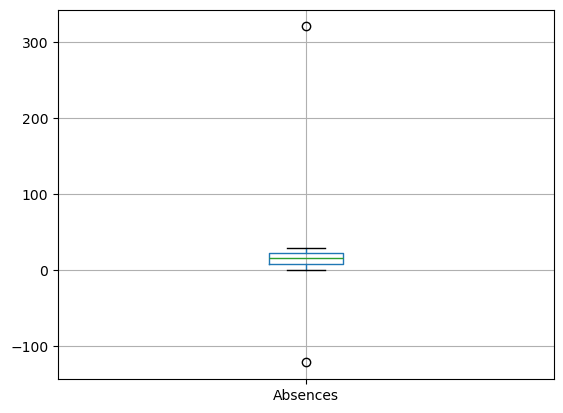

In [ ]:
df.boxplot(column="Absences")
plt.show()

From the boxplot above, we can see that there are two outliers on the high and low end.

In [ ]:
# Remove all the problem rows from df
df = df.drop(problem_rows.index)

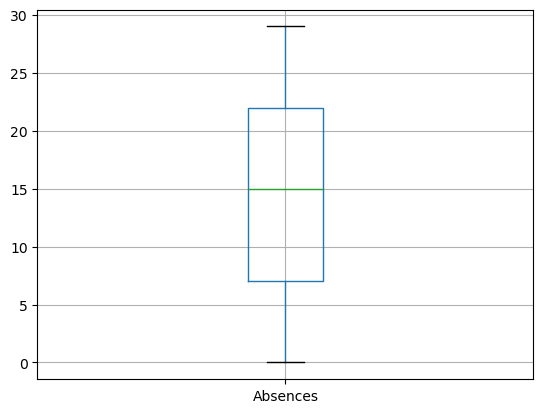

In [ ]:
df.boxplot(column="Absences")
plt.show()

After removing, we can see that there are no outliers anymore.

In [ ]:
df['Absences'].describe()

count    2098.000000
mean       14.628694
std         8.434995
min         0.000000
25%         7.000000
50%        15.000000
75%        22.000000
max        29.000000
Name: Absences, dtype: float64

### Explanation on why it is a data quality issue:
* The data quality issues I detected are two rows of unrealistic values for the 'Absences' column
* Row 112 has an absence value of 320, while row 1001 has an absence of -122
* Both of which are not possible, as it is not possible ot have negative absences, and 320 is higher than the toal number of school days in a year.
* If these two data are not removed, it can cause model that are trained on these erronous data to be less accurate

## Step 5: Audit consistency betwwen GPA and GradeClass

In [ ]:
df

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B
...,...,...,...,...,...,...,...
2095,3386,16,1.445434,20,3,1.395631,B
2096,3388,18,10.680555,2,4,3.455509,A
2097,3390,16,6.805500,20,2,1.142333,C
2098,3391,16,12.416653,17,2,1.803297,B


In [ ]:
# create a function to return the corresponding grade in characters
def assign_grade(gpa):
    if gpa >= 3.5:
        return 'A'
    elif gpa >= 3.0:
        return 'B'
    elif gpa >= 2.5:
        return 'C'
    elif gpa >= 2.0:
        return 'D'
    else:
        return 'F'

# Create a new dataframe based on GPA rules
df_expected = df['GPA'].apply(assign_grade)
df_expected.head()

0    B
1    F
2    D
3    F
4    B
Name: GPA, dtype: object

In [ ]:
inconsistent = df[df['GradeClass'] != df_expected]
inconsistent

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
2000,3182,15,3.253044,13,1,1.844056,B
2001,3183,17,17.086920,25,2,1.305585,C
2002,3189,16,5.697054,9,1,2.459805,B
2003,3193,16,15.827054,28,1,0.818126,C
2004,3195,15,15.615710,26,3,1.174610,A
...,...,...,...,...,...,...,...
2095,3386,16,1.445434,20,3,1.395631,B
2096,3388,18,10.680555,2,4,3.455509,A
2097,3390,16,6.805500,20,2,1.142333,C
2098,3391,16,12.416653,17,2,1.803297,B


In [ ]:
inconsistent_after = df[df['GradeClass'] != df_expected]
print("Number of Inconcsistencies:", len(inconsistent_after))

Number of Inconcsistencies: 100


## Exaplnation:
* The total number of students that has a GradeClass that does not match the GPA acccording to the cut off, is **100** students
* For instance, the student with StudentID 3195 has a GPA of 1.174610 and has a GradeClass of A, but it should have been an F.
* I decided to trust the GPA column, as it provides a more precise continuos value, while GradeClass is a derived categorical label from the GPA.

In [ ]:
# Update the dataframe so that GradeClass matches the GPA
df.loc[inconsistent.index, 'GradeClass'] = df_expected.loc[inconsistent.index]

In [ ]:
# Re-audit
inconsistent_after = df[df['GradeClass'] != df_expected]
print("Number of Inconcsistencies:", len(inconsistent_after))

Number of Inconcsistencies: 0


* Removed all inconsistencies in the dataframe by replacing each inconsistent row's GradeClass with the expected grade

---
# Part A2: Data Exploration and Visualisation (7 marks)

## 1. Calculate percentage of students for each GradeClass

In [ ]:
# Count number of students in each GradeClass
grade_counts = df['GradeClass'].value_counts()

# Calculate percentages
grade_percentages = df['GradeClass'].value_counts(normalize=True) * 100

print("\nPercentages per GradeClass:\n")
grade_percentages.round(2) # round to two decimal places



Percentages per GradeClass:



GradeClass
F    53.62
D    17.59
C    16.16
B     9.72
A     2.91
Name: proportion, dtype: float64

## 2. Pie Chart

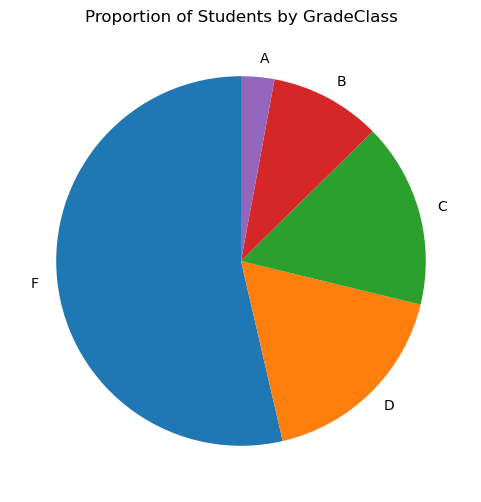

In [ ]:
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    grade_percentages, 
    labels=grade_percentages.index,
    startangle=90,       # rotate chart for better readability
)

plt.title("Proportion of Students by GradeClass")
plt.show()

**Observations:**
* The pie chart shows that the majority of students are in the have grades F, which maeans the majority of students have GPA of below 2.0
* Grade A student account for the smaller portion of the all students
* This shows a conerning level of underperformance from this group of students, as students with F account for more than half of all student's grades

## 3. Show slice percentage, comprared with A2.1

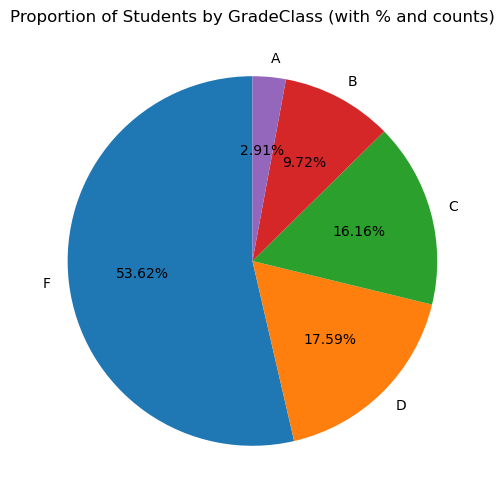

In [ ]:
# Pie chart with slice percentages
plt.figure(figsize=(6,6))
plt.pie(
    grade_percentages, 
    labels=grade_percentages.index, 
    autopct='%1.2f%%',
    startangle=90, 
)

plt.title("Proportion of Students by GradeClass (with % and counts)")
plt.show()

In [ ]:
grade_percentages.round(2)

GradeClass
F    53.62
D    17.59
C    16.16
B     9.72
A     2.91
Name: proportion, dtype: float64

**Explanations:**
* As we can observe, the percentage calculated by the slice percentage of the pie chart is the same as the percentages I calcualted in A2.1

## 4. Create visualisations for relation between Study Time & GPA

In [ ]:
df.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B


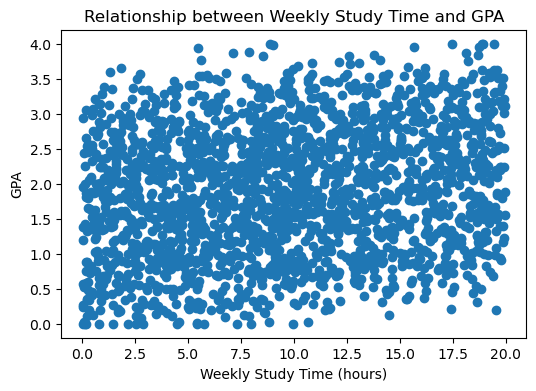

In [ ]:
# Create Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df['StudyTimeWeekly'], df['GPA'])
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("Relationship between Weekly Study Time and GPA")
plt.show()

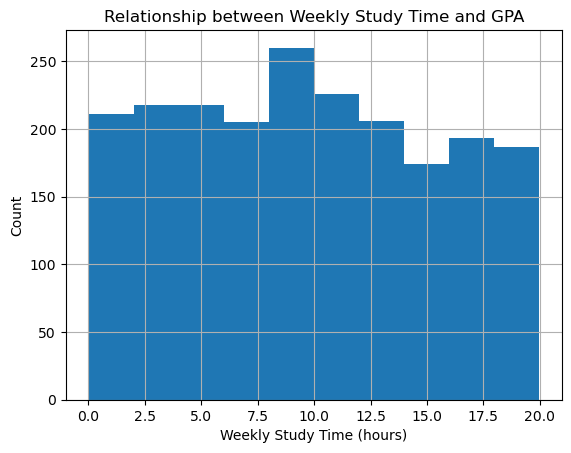

In [ ]:
df['StudyTimeWeekly'].hist(bins=10)
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("Count")
plt.title("Relationship between Weekly Study Time and GPA")
plt.show()

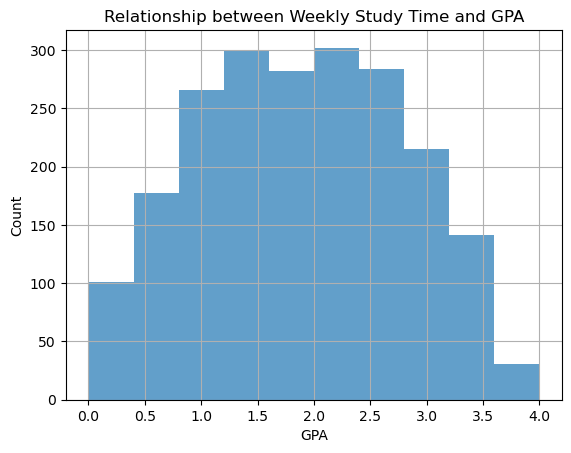

In [ ]:
df['GPA'].hist(bins=10, alpha=0.7)
plt.xlabel("GPA")
plt.ylabel("Count")
plt.title("Relationship between Weekly Study Time and GPA")
plt.show()

In [ ]:
correlation = df['StudyTimeWeekly'].corr(df['GPA'])
print("Correlation between StudyTimeWeekly and GPA:", correlation.round(5))


Correlation between StudyTimeWeekly and GPA: 0.17906


**Analysis/Explanations:**
* Looking at the scatter plot, it can be seen that there does not seem to be an obvious pattern between GPA and Weekly Study Time
* Having a correlation coefficitent fo 0.17906 suggest that there is a very weak positive correlation between weekly study time and GPA.

## 5. Correlation analysis between 'Absences' and 'GPA' 

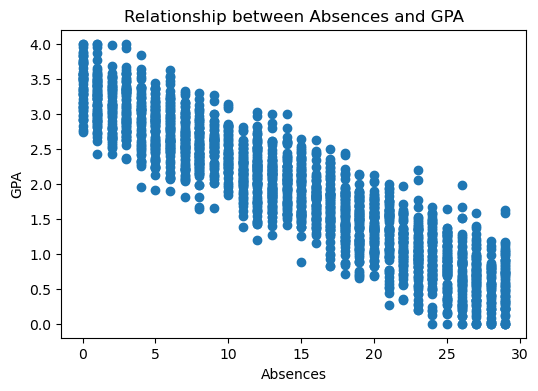

In [ ]:
# Create Scatter Plot between Absences and GPA

plt.figure(figsize=(6,4))
plt.scatter(df['Absences'], df['GPA'])
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.title("Relationship between Absences and GPA")
plt.show()

In [ ]:
correlation = df['Absences'].corr(df['GPA'])
print("Correlation between Absences and GPA:", correlation.round(5))

Correlation between Absences and GPA: -0.91978


**Explanations:**
* Making an analysis on the relationship between Absences and GPA in a scatter plot allows us to see a decreasing pattern
* Using the correlation functions, we can see that the correlation coefficient between Absences and GPA is -0.91978, which indicates a strong and negative correlation
* This means that, the more Absenses a student has, it will typically lead to a lower GPA.
* This pattern makes sense, as when student miss classes, it is more likely that the student would not be able to understand the subject well, which would lead to a lower test score, thus a lower GPA, and vice versa.

## 6. Correlation sufficient to conclude causation?

* Correlation alone is insufficient to conclude causation in this dataset.
* For example, even though Absences has a strong negative correlation with GPA (0.91978), it does not prove that abcenses directly causes low GPA. It is that other there are other factors causes both of these to occur simultaneosly, such as students with low motivation, skip both calsses and achieve low grades. Or there are family or health issues that contribute to missing classses and poorer academic results.
* Thus, it is not right to say that correlation is sufficient to prove the cause.

To stregnthen the claims, it is recommended to involve additional data, such as the socioeconomic background of the students. This allows us additional information to compare with our existing data, which can futher prove or disprove whethen our correlation is the genuine cause.

## 7. Group by 'GradeClass' with GPA and Absences

In [ ]:
# Group by GradeClass and compute required stats
agg_stats = df.groupby('GradeClass').agg({
    'GPA': ['mean', 'median', 'std', lambda x: np.percentile(x, 75) - np.percentile(x, 25)],
    'Absences': ['mean', 'median', 'std', lambda x: np.percentile(x, 75) - np.percentile(x, 25)]
})

# Rename lambda columns to 'IQR'
agg_stats.rename(columns={'<lambda_0>': 'IQR'}, inplace=True)

# Display the results
agg_stats

GPA                                 Absences         \
                mean    median       std       IQR       mean median   
GradeClass                                                             
A           3.681490  3.618273  0.163589  0.275281   1.475410    1.0   
B           3.227285  3.219432  0.143109  0.242832   3.308824    3.0   
C           2.732964  2.723828  0.145818  0.250655   6.433628    6.0   
D           2.249837  2.240924  0.137388  0.230745  11.140921   11.0   
F           1.181513  1.234141  0.513394  0.788061  21.008000   21.0   

                           
                 std  IQR  
GradeClass                 
A           1.659383  3.0  
B           2.500782  4.0  
C           3.562318  5.0  
D           3.783787  6.0  
F           5.033246  8.0

## 8. Flatten into single level columns

In [ ]:
# Flatten MultiIndex to single-level column names
agg_stats.columns = [f"{col[0]}_{col[1]}" for col in agg_stats.columns]

# Display tidy DataFrame
agg_stats.reset_index(inplace=True)
agg_stats


,GradeClass,GPA_mean,GPA_median,GPA_std,GPA_IQR,Absences_mean,Absences_median,Absences_std,Absences_IQR
0,A,3.681490,3.618273,0.163589,0.275281,1.475410,1.0,1.659383,3.0
1,B,3.227285,3.219432,0.143109,0.242832,3.308824,3.0,2.500782,4.0
2,C,2.732964,2.723828,0.145818,0.250655,6.433628,6.0,3.562318,5.0
3,D,2.249837,2.240924,0.137388,0.230745,11.140921,11.0,3.783787,6.0
4,F,1.181513,1.234141,0.513394,0.788061,21.008000,21.0,5.033246,8.0


---
# Part A3: Supervised Learning (3 Marks)

## 1. Explain Supervised Machine Learning, Training and Testing sets

**Supervised Machine Learning** with GradeClass:\
Supervised machine learning is a method where a model learns from labeled data, meaning the input features are provided along with the correct output labels. In this dataset, the label is GradeClass, which represents the student’s grade category. The model will learn patterns in the input features (e.g., GPA, study time, absences) to predict GradeClass for new students.

**Training vs Testing**
* **Training**: The portion of the dataset used to fit the model, i.e., to learn patterns between features and the label.
* **Testing**: A separate portion of the dataset that the model has never seen before, used to evaluate how well it generalises to unseen data.

**Risk of not holding out a test set**\
If no test set is used, the model might only appear to perform well on the training data but fail to generalise. This is called overfitting. In such cases, the model memorises the training data instead of learning true underlying patterns, leading to poor accuracy on new students.

## 2. Saperate features from label

In [ ]:
df.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B


**Exlude *StudentID* and *GPA*:**
* StudentID should be exlucded as it is just an identifier, it does not affect the GPA outcome which is used to determined
* GPA overlaps with the label, as the GPA directly allows us to determined what the GradeClass would be using the stated cutoffs

**Include the rest:**
* Age - This may influence academic performance
* StudyTimeWeekly - while previously shown weakly correlated, it can still provide information to determine GPA
* Absences - It has strong correlation with GPA, extremely useful for prediction
* ParentalSupport - It can highly affect the outcome of GPA

In [ ]:
y = df['GradeClass']

X = df.drop(columns=['StudentID', 'GPA', 'GradeClass']) # Drop GradeClass also, because it is the label

print("Features used:", X.columns.tolist())
print("Label:", y.name)

Features used: ['Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport']
Label: GradeClass


## 3. Split data into training and testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 1468
Testing set size: 630


**Explanation:**
I split the dataset into 70% training and 30% testing using train_test_split. This resulted in 1127 samples in the training set and 484 samples in the testing set. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

If the dataset were very small, I would not use a strict 70/30 split because the testing set might end up too small to be representative.

---
# Part A4: Classification (training) (5 marks)

## 1. Normalization and Scaling

**Explanation: Part A - Why is normalisation neccessary?**
* Normalisation is neccesary for models like SVM, as we are using features with very different scales
* Classifiers typically calculate the dsitance between points using Eucleadean distance.
* In other words, if the features are not normalised, the larger-valued features will dominate the prediction model
* For example:
    * ParentalSupport ranges from from 0-4
    * StudyTimeWeekly ranges form 0.004859 to 19.978094
    * If not normalised, the model will treat a 10 unit differenc in StudyTimeWeekly more importantly than a 4 unit difference in ParentalSupport

Similar to Week 7, we also have to normalise the data points into Z-Scores before we can apply the Decision Tree Algorithm.

In [ ]:
df.describe()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA
count,2098.000000,2098.000000,2098.000000,2098.000000,2098.000000,2098.000000
mean,2063.321735,16.476168,9.675259,14.628694,2.116301,1.891708
std,626.912674,1.124850,5.636410,8.434995,1.120244,0.908317
min,1002.000000,15.000000,0.004859,0.000000,0.000000,0.000000
25%,1527.250000,15.000000,4.937242,7.000000,1.000000,1.171762
50%,2052.500000,16.000000,9.513101,15.000000,2.000000,1.881444
75%,2576.750000,17.000000,14.282893,22.000000,3.000000,2.604002
max,3392.000000,18.000000,19.978094,29.000000,4.000000,4.000000


**Scaling and Nomalisation: Part B**
* I scaled the numerical columns Age, StudyTimeWeekly, Absences, and ParentalSupport using StandardScaler from sklearn.preprocessing.
* This will give each feature a mean of almost 0 and a standard deviation of almost 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to scale (numerical features only, exclude categorical or label)
cols_to_scale = ['Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport']

scaler = StandardScaler()

# Make copies of the X_train and X_test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply scalar to normalize
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled.describe()
X_test_scaled.describe()

,Age,StudyTimeWeekly,Absences,ParentalSupport
count,630.000000,630.000000,630.000000,630.000000
mean,0.042364,0.004310,0.020951,-0.092073
std,0.998095,0.993019,0.998926,1.011606
min,-1.299101,-1.710828,-1.727516,-1.925072
25%,-1.299101,-0.818595,-0.897869,-1.028496
50%,0.478234,-0.027416,0.050299,-0.131921
75%,1.366901,0.807875,0.879946,0.764654
max,1.366901,1.820140,1.709593,1.661229


In [ ]:
X_test_scaled.describe()

,Age,StudyTimeWeekly,Absences,ParentalSupport
count,630.000000,630.000000,630.000000,630.000000
mean,0.042364,0.004310,0.020951,-0.092073
std,0.998095,0.993019,0.998926,1.011606
min,-1.299101,-1.710828,-1.727516,-1.925072
25%,-1.299101,-0.818595,-0.897869,-1.028496
50%,0.478234,-0.027416,0.050299,-0.131921
75%,1.366901,0.807875,0.879946,0.764654
max,1.366901,1.820140,1.709593,1.661229


## 2. Building the SVM (Support Vector Machine) Model

**a. Describe Support Vector Machine (SVM)**
* Support Vector Machine (SVM) is a supervised machine learning algorithm mainly used for classification.
* It works by finding the optimal decision boundary, or the hyperplane, that best separates classes in the feature space.
* The support vectors are the critical data points closest to this boundary; they influence the position of the hyperplane.
* SVM aims to maximise the margin between classes, making the model more robust to noise.

**b. Kernal**
* As many datasets cannot be saperated linearly in their original form, a kernel has to be used.
* A kernel function transform the data into a higher-duimensional space to allow the saperation to be possible.
* Types of kernel:
    * Linear kernel: good if classes are already separable in input space.
    * Polynomial kernel: useful for curved decision boundaries.
    * RBF (Radial Basis Function): most common, captures complex nonlinear patterns.

**c. Write the predictive SVM model**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Initialise SVM classifier (RBF kernel is default and handles non-linear separation)
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

## 3. Train another classifier

**Additional Classfier: *Random Forest Algorithm***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train) # Training model, use X and y train

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

---
# Part A5. Classification (prediction) (5 marks)

## 1. Predict values using SVM and Random Forest

In [ ]:
# Predict using SVM model
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
# Predict using Random Forest model
y_pred_rf = rf_model.predict(X_test_scaled) # when predicting, give it the X_test data set\

## 2. Display the confusion matrix

In [ ]:
# SVM
# Evaluate performance
print("-----SVM------\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

-----SVM------

Confusion Matrix:
 [[  0  13   5   0   0]
 [  1  38  21   1   0]
 [  0   8  68  24   2]
 [  0   0  27  49  35]
 [  0   0   2  19 317]]

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00        18
           B       0.64      0.62      0.63        61
           C       0.55      0.67      0.60       102
           D       0.53      0.44      0.48       111
           F       0.90      0.94      0.92       338

    accuracy                           0.75       630
   macro avg       0.52      0.53      0.53       630
weighted avg       0.73      0.75      0.74       630



In [ ]:
# Random Forest
# Evaluate performance
print("-----RANDOM FOREST------\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

-----RANDOM FOREST------

Confusion Matrix:
 [[  3   7   8   0   0]
 [  6  36  19   0   0]
 [  1  21  56  23   1]
 [  0   2  30  50  29]
 [  0   0   3  20 315]]

Classification Report:
               precision    recall  f1-score   support

           A       0.30      0.17      0.21        18
           B       0.55      0.59      0.57        61
           C       0.48      0.55      0.51       102
           D       0.54      0.45      0.49       111
           F       0.91      0.93      0.92       338

    accuracy                           0.73       630
   macro avg       0.56      0.54      0.54       630
weighted avg       0.72      0.73      0.73       630



**Frequent Confusion**
* One of the most frequent confusion is between D and F in the SVM model
* True D was predicted as F 35 times
* True F was predicted as D 19 times
* **Possible Causes:**
    1. Overlapping features:
       * D students with high rate of absences and low study time may appear to look like F students
       * On the contrary, F students with lower rate of absences and higher study time appear to look like D students
    2. Class Imbalance:
       * F has the largest class (338 samples)
       * Classfiers tend to be bias towards the calss with larger data
       * This can lead to miscalculations
    3. Vague Boundary:
       * The differnce in features between D and F students may be very subtle
       * SVM may create a smooth boundary, so some points fall on the wrong side

## 3. Compare performance of SVM and Random Forest

**Overall Accuracy:**
* SVM: 0.75
* Random Forest: 0.73

**Weighted Accuracy:**
* SVM: 0.74
* Random Forest: 0.73

**Conclusion:**\
SVM is generally the better performer for your dataset because it captures non-linear boundaries between adjacent grades, improving overall accuracy and weighted F1.

## 4. Bias or Variance

* High bias leads to underfitting
* High Variance leads to overfitting

### SVM Model:
* From the values that in the confusion matrix, we can observ that the minority classes like A completely cannot be predicted
* This shows that the SVM has **underfitted** the dataset.
* In other words, it more likely to suffer from **high bias**

### Random Forest Model:
* The random forest model can predict True A outcomes with an accuracy of, 0.30
* But its has an overall lower accuracy with 0.73

---
# Part A6: Independent evaluation (5 Marks)

In [ ]:
df_extra = pd.read_csv("Student_List_A2_Submission.csv")

In [ ]:
df_extra.shape

(161, 5)

In [ ]:
df_extra

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport
0,5000,16,13.274090,27,1
1,5001,17,16.926360,6,2
2,5002,15,4.225258,15,3
3,5003,16,18.839829,17,3
4,5004,15,9.075075,6,2
...,...,...,...,...,...
156,5156,16,19.078416,15,4
157,5157,16,8.052229,24,1
158,5158,16,11.660373,27,1
159,5159,15,16.744383,8,2


In [ ]:
df_extra.describe()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport
count,161.000000,161.000000,161.000000,161.000000,161.000000
mean,5080.000000,16.428571,10.314005,15.217391,2.285714
std,46.620811,1.105183,5.601883,8.367120,1.114835
min,5000.000000,15.000000,0.001057,0.000000,0.000000
25%,5040.000000,15.000000,5.805674,8.000000,2.000000
50%,5080.000000,16.000000,10.437689,15.000000,2.000000
75%,5120.000000,17.000000,14.736337,23.000000,3.000000
max,5160.000000,18.000000,19.198334,29.000000,4.000000


In [ ]:
student_ids = df_extra['StudentID']

In [ ]:
X_train = df_extra.drop(columns=['StudentID'])

cols_to_scale = ['Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport']

scaler = StandardScaler()
X_train_scaled = X_train.copy()

# Apply scalar to normalize
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train_scaled

,Age,StudyTimeWeekly,Absences,ParentalSupport
0,-0.388993,0.530058,1.412597,-1.156876
1,0.518658,1.184064,-1.105058,-0.257084
2,-1.296644,-1.090302,-0.026063,0.642709
3,-0.388993,1.526706,0.213714,0.642709
4,-1.296644,-0.221853,-1.105058,-0.257084
...,...,...,...,...
156,-0.388993,1.569429,-0.026063,1.542501
157,-0.388993,-0.405013,1.052932,-1.156876
158,-0.388993,0.241092,1.412597,-1.156876
159,-1.296644,1.151477,-0.865281,-0.257084


In [ ]:
pred_y_extra = svm_model.predict(X_train_scaled)
pred_y_extra

array(['F', 'C', 'F', 'D', 'C', 'C', 'C', 'F', 'C', 'F', 'F', 'F', 'F',
       'C', 'F', 'C', 'F', 'D', 'D', 'C', 'F', 'F', 'C', 'C', 'F', 'F',
       'B', 'F', 'F', 'F', 'F', 'F', 'B', 'F', 'F', 'C', 'B', 'F', 'F',
       'F', 'F', 'F', 'C', 'C', 'F', 'D', 'B', 'F', 'C', 'F', 'B', 'D',
       'F', 'F', 'C', 'F', 'D', 'F', 'F', 'F', 'F', 'C', 'B', 'D', 'D',
       'F', 'F', 'F', 'F', 'D', 'C', 'F', 'F', 'D', 'F', 'C', 'F', 'F',
       'D', 'F', 'C', 'B', 'F', 'A', 'F', 'B', 'C', 'C', 'F', 'F', 'C',
       'F', 'F', 'C', 'B', 'F', 'F', 'F', 'F', 'F', 'C', 'C', 'F', 'D',
       'F', 'D', 'C', 'F', 'D', 'F', 'D', 'F', 'D', 'F', 'F', 'F', 'B',
       'D', 'F', 'C', 'F', 'D', 'B', 'F', 'F', 'F', 'C', 'F', 'F', 'F',
       'F', 'B', 'B', 'F', 'C', 'B', 'C', 'F', 'F', 'F', 'F', 'C', 'D',
       'B', 'F', 'F', 'F', 'F', 'F', 'F', 'D', 'F', 'C', 'D', 'F', 'F',
       'D', 'F', 'F', 'C', 'F'], dtype=object)

In [ ]:
# Mapping dictionary
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}

# Convert letters to numbers
grades_num = np.vectorize(grade_map.get)(pred_y_extra)
grades_num

array([4, 2, 4, 3, 2, 2, 2, 4, 2, 4, 4, 4, 4, 2, 4, 2, 4, 3, 3, 2, 4, 4,
       2, 2, 4, 4, 1, 4, 4, 4, 4, 4, 1, 4, 4, 2, 1, 4, 4, 4, 4, 4, 2, 2,
       4, 3, 1, 4, 2, 4, 1, 3, 4, 4, 2, 4, 3, 4, 4, 4, 4, 2, 1, 3, 3, 4,
       4, 4, 4, 3, 2, 4, 4, 3, 4, 2, 4, 4, 3, 4, 2, 1, 4, 0, 4, 1, 2, 2,
       4, 4, 2, 4, 4, 2, 1, 4, 4, 4, 4, 4, 2, 2, 4, 3, 4, 3, 2, 4, 3, 4,
       3, 4, 3, 4, 4, 4, 1, 3, 4, 2, 4, 3, 1, 4, 4, 4, 2, 4, 4, 4, 4, 1,
       1, 4, 2, 1, 2, 4, 4, 4, 4, 2, 3, 1, 4, 4, 4, 4, 4, 4, 3, 4, 2, 3,
       4, 4, 3, 4, 4, 2, 4])

In [ ]:
submission_df = pd.DataFrame({
    'StudentID': student_ids,
    'GradeClass': grades_num
})

In [ ]:
print(submission_df.shape)

(161, 2)


In [ ]:
submission_df

,StudentID,GradeClass
0,5000,4
1,5001,2
2,5002,4
3,5003,3
4,5004,2
...,...,...
156,5156,3
157,5157,4
158,5158,4
159,5159,2


In [ ]:
submission_df.to_csv('35624914-QuahXuanyu-v1.csv', index=False)

---
# Part B: Selection of Dataset and perform Clustering (7 Marks)

## 1. Select Dataset
* Link to dataset: https://www.kaggle.com/datasets/vikasjigupta786/customer-analytics-practice-dataset
* The dataset that I have chosen is the **Customer Analytics Practice Dataset**

In [ ]:
df = pd.read_csv("Mall_Customers_Enhanced.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget


In [ ]:
df.shape

(200, 10)

## 2. Data Wrangling

In [ ]:
# Check which columns has missing values
print("Missing Data (Before)")
print(df.isnull().sum())

Missing Data (Before)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 4
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64


**We can see that Age Group has missing 4 data**\
**Since we have over 200 records. To make the data accurate is clean, I will just remove the rows with missing data in the column**

In [ ]:
df = df.replace('*', np.nan) # incase there are any '*' symbols for empty data, convert it to NaN
df = df.dropna() # Remove all NaN rows

In [ ]:
print("Missing Data (After)")
# Check which columns has missing values
print(df.isnull().sum())

Missing Data (After)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 0
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64


In [ ]:
# Check the datatype
df.dtypes

CustomerID                  int64
Gender                     object
Age                         int64
Annual Income (k$)          int64
Spending Score (1-100)      int64
Age Group                  object
Estimated Savings (k$)    float64
Credit Score                int64
Loyalty Years               int64
Preferred Category         object
dtype: object

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Estimated Savings (k$),Credit Score,Loyalty Years
count,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000
mean,100.984694,39.275510,60.750000,50.000000,40.411429,744.612245,5.964286
std,58.208685,13.785374,26.441105,25.897431,21.442940,154.496710,1.560325
min,1.000000,19.000000,15.000000,1.000000,6.460000,300.000000,2.000000
25%,50.750000,29.000000,41.500000,33.500000,28.800000,698.750000,5.000000
50%,101.500000,36.000000,62.000000,50.000000,36.410000,833.000000,6.000000
75%,151.250000,49.000000,78.000000,73.000000,45.307500,850.000000,7.000000
max,200.000000,70.000000,137.000000,99.000000,120.560000,850.000000,9.000000


## 3. Perform K-Means

In [ ]:
# Choose the 2 numerical featrues (age and spending score)
x_val = 'Age'
y_val = 'Spending Score (1-100)'
df = df[[x_val, y_val]]
df

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40
...,...,...
195,35,79
196,45,28
197,32,74
198,32,18


* Looking at the raw data scatter plot I predict that there will be 4 clusters, namely:
    * Younger high-spenders
    * Younger low-spenders,
    * Older moderate-spenders
    * Older high-spenders
* Thus, I choose to use **k = 4** for me k clusters

In [ ]:
from sklearn.cluster import KMeans

# run the kmeans function
kmeans = KMeans(n_clusters=4).fit(
    df[[x_val,y_val]] 
)

C:\Software\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Software\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Software\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Software\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Look at the outputs: Four cluster centers 
kmeans.cluster_centers_ 
# Look at the outputs: Cluster labels  
kmeans.labels_

array([2, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 2, 2, 3, 0, 2, 0,
       3, 0, 3, 0, 3, 2, 3, 0, 3, 0, 3, 3, 0, 3, 0, 3, 0, 1, 0, 1, 2, 3,
       2, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 1, 1, 1, 1, 2, 2, 2, 0, 2, 0, 1, 0, 3, 0, 3, 0, 2, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 2, 0, 3, 0, 1, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 1, 0, 3, 0, 3, 0, 3, 0, 3, 2, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0],
      dtype=int32)

## 4. Visualisation (Raw and Clustered)

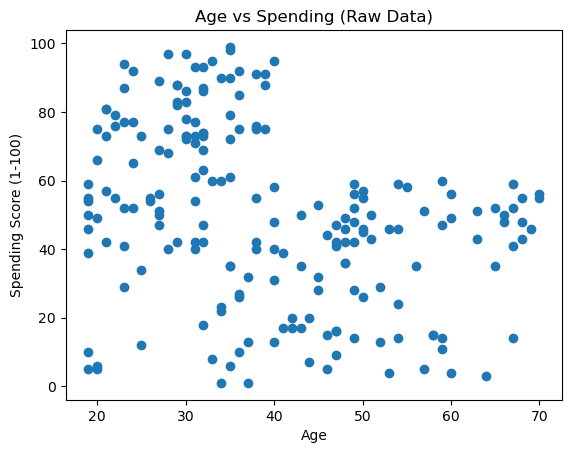

In [ ]:
# Raw data on scatter plot
plt.scatter(x=df[x_val], y=df[y_val])
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending (Raw Data)");
plt.show()

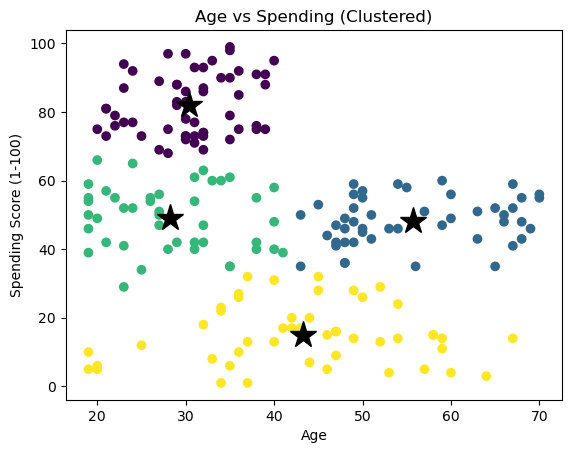

In [ ]:
# Visualise the output labels 
plt.scatter( 
    x=df[x_val], 
    y=df[y_val],  
    c=kmeans.labels_) 
# Visualise the cluster centers (black stars) 
plt.plot( 
    kmeans.cluster_centers_[:,0], 
    kmeans.cluster_centers_[:,1], 
    'k*', 
    markersize=20 
) 
plt.xlabel(x_val) 
plt.ylabel(y_val)
plt.title("Age vs Spending (Clustered)");
plt.show()

## 5. Why this data set for K-Means?
* The reason I choose this data set is that I forsee that there is a correlation pattern between Age and Spending Score are numerical values
* Between age and speding habits, I can also see how different age groups have different spending habits.
* This can lead to a pattern of clustering, which is suitable for K-Means

## 6. Patterns - expected and results
* Before clustering, I forsee that there will be a cluster for:
    * Younger high-spenders
    * Younger low-spenders,
    * Older moderate-spenders
    * Older high-spenders
* However, upon making the K-means graph, it appears that there are the following clusters:
    * Younger high-spenders
    * Younger moderate-spenders
    * Older moderate-spenders
    * Low-spenders (all ages)

* Thre results were mostly in line with my expectations. However, it seems that there are no older high spenders.
* This can be due to the fact that older people are in retirement age, where they do not have active income, and do not need to spend that much.